In [2]:
import geopandas as gpd
import pandas as pd

In [12]:
assessment_roll_vic = pd.read_csv('2025/2025 victoria.csv')
properties_raw = gpd.read_file('parcels/raw_download.geojson')

In [ ]:
#Assessment roll contains duplicate values for assess_type of GENERAL AND SCHOOL. Drop SCHOOL and only keep GENERAL.
assessment_roll = assessment_roll_vic[assessment_roll_vic['assess_type'] != 'SCHOOL']
properties = properties_raw.copy()
#remove the jurisdiction code from properties.Folio 0 - everything that preceeds the first period
properties['Folio'] = properties['Folio'].str.split('.').str[1]
#remove non-numeric characters from properties.Folio
properties['Folio'] = properties['Folio'].str.replace(r'\D', '', regex=True)
#convert to int
properties['Folio'] = properties['Folio'].astype(int)

#left merge properties with assessment_roll on Folio and FOLIO
merged = properties.merge(assessment_roll, left_on='Folio', right_on='FOLIO', how='left')

#drop everything except for: FullAddress, Folio, LEGAL_TYPE, assess_abbreviation, land_gross, impr_gross, geometry
merged = merged[['FullAddress', 'Folio', 'LEGAL_TYPE', 'assess_abbreviation', 'land_gross', 'impr_gross', 'geometry']]

#aggregate by common geometry. Sum land_gross and impr_gross, use First for everything else
merged = merged.groupby('geometry').agg({
    'FullAddress': 'first',
    'Folio': 'first',
    'LEGAL_TYPE': 'first',
    'assess_abbreviation': 'first',
    'land_gross': 'sum',
    'impr_gross': 'sum'
}).reset_index()

merged['total_gross'] = merged['land_gross'] + merged['impr_gross']

#convert back to geopandas gdf
merged = gpd.GeoDataFrame(merged, geometry='geometry')

#calculate the area in M2
merged['area'] = merged['geometry'].area
merged['total per m2'] = merged['total_gross'] / merged['area']

0        234.13-100-037
1        234.13-100-010
2        234.13-099-103
3        234.13-099-102
4        234.13-099-101
              ...      
33992    234.05-315-070
33993    234.01-091-016
33994    234.01-091-015
33995    234.01-051-022
33996    234.01-014-026
Name: Folio, Length: 33997, dtype: object


<Axes: >

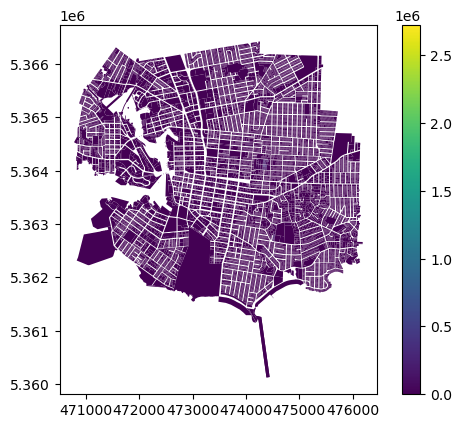

In [14]:
merged.plot(column='total per m2', legend=True)